# Plain-English writing rules for Claude Code: how the variants pan out

[vivarium-suite PR #304](https://github.com/ihmeuw/vivarium-suite/pull/304) adds plain-English writing rules, based on ASD-STE100 Simplified Technical English, to the `simsci` plugins: a one-line rule in nine agent definitions and a 427-character `SessionStart` hook text for the main session. The PR's own evals found that *naming* the standard in the text made output less clear and less complete, so the shipped text spells out the rules and does not say "ASD-STE100".

[Karpathy's thread](https://twitter-thread.com/t/2105819303471976479) (2 Oct) suggests the opposite shortcut: just ask the model to "explain something in ASD-STE100", or soften it to "80% of the way to ASD-STE100". He also suggests asking for a diagram, an HTML page, or a video instead of prose.

This notebook runs both families of instruction, plus the PR's rejected "named" variant, through the same four writing tasks and compares the outputs: side by side, with surface style metrics, and with a blind LLM judge.

**Setup.** Each cell is one headless Claude Code call (`claude -p`, model `claude-opus-5-5`, tools disabled, fresh temporary working directory, no settings files). The variant text is appended to the default Claude Code system prompt. Seven variants x four tasks x five repetitions = 140 runs. A blind judge (also `claude-opus-5-5`, with its own system prompt and a JSON schema) scores each text on clarity, accuracy, completeness, and actionability (1 to 5), lists which planted facts the text states, and lists which traps it states as fact. The judge never sees the variant name.

**Read the numbers with care.** Five repetitions per cell give wide intervals. The tasks are small and synthetic. The judge is a model, and its criteria overlap with the rules under test (the PR notes the same limit). Treat differences whose interval crosses zero as noise.

In [1]:
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 220)

from analyze import COST_COLS, JUDGE_COLS, PRETTY, STYLE_COLS, delta_vs, load_all, summarize, wide_table
from plots import bar_panels, dot_plot, heatmap
from tasks import ORDER as TORDER
from tasks import TASKS
from variants import ORDER as VORDER
from variants import VARIANTS

df = load_all()
print(f"{len(df)} runs: {df.variant.nunique()} variants x {df.task.nunique()} tasks x {df.rep.nunique()} reps, model {df.model.iloc[0]}")
print(f"generation cost ${df.cost_usd.sum():.2f}" + (f", judge cost ${df.judge_cost_usd.sum():.2f}" if "judge_cost_usd" in df else ""))

140 runs: 7 variants x 4 tasks x 5 reps, model claude-opus-5-5
generation cost $6.17, judge cost $5.99


## The variants

V1 and V2 are copied verbatim from the PR. V3 is the PR's eval-round-5 text that names the standard. V4 to V6 follow Karpathy's thread.

In [2]:
pd.DataFrame(
    [{"variant": k, "label": v["label"], "source": v["source"], "chars": len(v["text"] or ""), "text appended to the system prompt": v["text"] or "(nothing)"} for k, v in VARIANTS.items()]
).set_index("variant")

,label,source,chars,text appended to the system prompt
variant,,,,
none,V0 no rules (control),control,0,(nothing)
pr_agent_line,V1 PR one-line agent rule,"PR #304 (shipped, agents)",241,"Write prose for people in plain technical English. Use short sentences in the active voice and simple tenses, and one name for each thing. Do not use semicolons, Latin abbreviations, or metaphors. Put code identifiers and paths in backticks."
pr_hook_text,V2 PR hook text (427 chars),"PR #304 (shipped, SessionStart hook)",426,"Prose for people in this project is plain technical English. Sentences are short, in the active voice, and in simple tenses. Each thing has one name. The text has no semicolons, contractions, Latin abbreviations, or metaphors. Code identifiers and paths are in backticks. A guess or a judgment is marked as one, and a reason that the source does not give is not stated as fact. Code and quoted text keep their own conventions."
pr_hook_named,V3 PR hook text + names ASD-STE100,PR #304 eval round 5 (rejected),476,"Prose for people in this project is plain technical English, based on ASD-STE100 Simplified Technical English. Sentences are short, in the active voice, and in simple tenses. Each thing has one name. The text has no semicolons, contractions, Latin abbreviations, or metaphors. Code identifiers and paths are in backticks. A guess or a judgment is marked as one, and a reason that the source does not give is not stated as fact. Code and quoted text keep their own conventions."
ste_named,V4 'Write in ASD-STE100',Karpathy thread,51,Write in ASD-STE100 (Simplified Technical English).
ste_80pct,V5 '80% of the way to ASD-STE100',Karpathy thread,66,Write 80% of the way to ASD-STE100 (Simplified Technical English).
diagram,V6 prefer a diagram,Karpathy thread,171,"Prefer a diagram over prose. When the content has a structure, a sequence, or dependencies, show it as a Mermaid or plain-text diagram, and keep the prose around it short."


## The tasks

The tasks mirror the PR's eval cases: a PR description, a Jira ticket, the PR's exact chat prompt, and a documentation review with planted issues. Each task carries a list of facts the source supports and a list of traps (claims the source does not support). The writer sees only the prompt; the judge sees everything.

In [3]:
pd.DataFrame([{"task": k, "title": t["title"], "facts": len(t["facts"]), "traps": len(t["traps"])} for k, t in TASKS.items()]).set_index("task")

,title,facts,traps
task,,,
pr_description,PR description for a retry-default change,6,4
jira_ticket,Jira bug ticket for a config loader strict-mode default,6,4
chat_reply,Chat reply: what the change does and what could break,6,4
doc_review,Documentation review with planted issues,6,3


## Blind judge scores by variant

Means over 4 tasks x 5 reps, with 95% bootstrap intervals. `Facts recalled` is the share of the task's planted facts that the judge found stated correctly in the text.

In [4]:
wide_table(df, JUDGE_COLS)

,Clarity (1-5),Accuracy (1-5),Completeness (1-5),Actionability (1-5),Facts recalled (share)
V0 no rules (control),"4.80 [4.60, 4.95]","4.35 [4.00, 4.65]","4.90 [4.75, 5.00]","4.95 [4.85, 5.00]","0.97 [0.95, 1.00]"
V1 PR one-line agent rule,"4.85 [4.70, 5.00]","4.55 [4.25, 4.80]","4.95 [4.85, 5.00]","5.00 [5.00, 5.00]","0.98 [0.96, 1.00]"
V2 PR hook text (427 chars),"4.90 [4.75, 5.00]","4.70 [4.50, 4.90]","5.00 [5.00, 5.00]","5.00 [5.00, 5.00]","1.00 [1.00, 1.00]"
V3 PR hook text + names ASD-STE100,"4.90 [4.75, 5.00]","4.75 [4.55, 4.90]","5.00 [5.00, 5.00]","5.00 [5.00, 5.00]","1.00 [1.00, 1.00]"
V4 'Write in ASD-STE100',"4.85 [4.70, 5.00]","4.30 [4.05, 4.55]","4.95 [4.85, 5.00]","4.95 [4.85, 5.00]","0.98 [0.96, 1.00]"
V5 '80% of the way to ASD-STE100',"4.90 [4.75, 5.00]","4.35 [4.10, 4.60]","4.85 [4.70, 5.00]","4.95 [4.85, 5.00]","0.97 [0.95, 1.00]"
V6 prefer a diagram,"4.55 [4.35, 4.75]","4.25 [3.90, 4.55]","4.90 [4.75, 5.00]","4.95 [4.85, 5.00]","0.98 [0.96, 1.00]"


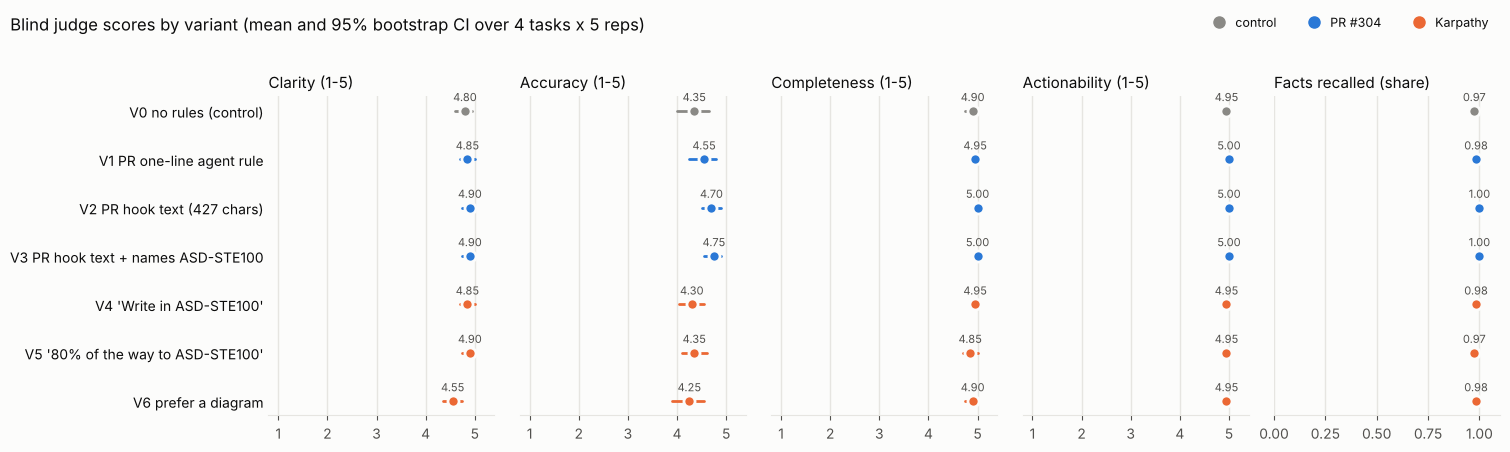

In [5]:
s = summarize(df, JUDGE_COLS)
fig = dot_plot(
    s, JUDGE_COLS,
    "Blind judge scores by variant (mean and 95% bootstrap CI over 4 tasks x 5 reps)",
    xlim={c: (0.8, 5.4) for c in JUDGE_COLS[:-1]} | {"facts_recall": (0, 1.1)},
)

### Difference from the control (no rules), paired by task and rep

A positive number means the variant scored higher than the control on the same task and repetition.

In [6]:
d = delta_vs(df, JUDGE_COLS, ref="none")
d["cell"] = d.apply(lambda r: f"{r['delta']:+.2f} [{r['lo']:+.2f}, {r['hi']:+.2f}]", axis=1)
w = d.pivot(index="label", columns="metric", values="cell")[JUDGE_COLS]
w.columns = [PRETTY[c] for c in w.columns]
w.index.name = None
w.loc[[VARIANTS[v]["label"] for v in VORDER if v != "none"]]

,Clarity (1-5),Accuracy (1-5),Completeness (1-5),Actionability (1-5),Facts recalled (share)
V1 PR one-line agent rule,"+0.05 [-0.15, +0.25]","+0.20 [-0.05, +0.45]","+0.05 [-0.10, +0.20]","+0.05 [+0.00, +0.15]","+0.01 [-0.02, +0.03]"
V2 PR hook text (427 chars),"+0.10 [-0.10, +0.30]","+0.35 [+0.00, +0.70]","+0.10 [+0.00, +0.25]","+0.05 [+0.00, +0.15]","+0.02 [+0.00, +0.05]"
V3 PR hook text + names ASD-STE100,"+0.10 [-0.15, +0.35]","+0.40 [+0.05, +0.75]","+0.10 [+0.00, +0.25]","+0.05 [+0.00, +0.15]","+0.02 [+0.00, +0.05]"
V4 'Write in ASD-STE100',"+0.05 [-0.20, +0.30]","-0.05 [-0.40, +0.30]","+0.05 [-0.10, +0.20]","+0.00 [-0.15, +0.15]","+0.01 [-0.02, +0.03]"
V5 '80% of the way to ASD-STE100',"+0.10 [-0.15, +0.35]","+0.00 [-0.35, +0.35]","-0.05 [-0.25, +0.15]","+0.00 [+0.00, +0.00]","+0.00 [-0.04, +0.04]"
V6 prefer a diagram,"-0.25 [-0.50, +0.00]","-0.10 [-0.40, +0.20]","+0.00 [-0.15, +0.15]","+0.00 [-0.15, +0.15]","+0.01 [-0.02, +0.03]"


## Surface style metrics

Deterministic counts on the prose (code blocks and inline code removed). ASD-STE100 asks for sentences of at most 20 words in procedures (25 in descriptions), no semicolons, and the active voice. `Passive hits` is a regex heuristic (a form of *be* followed by a past participle), so read it as a rough rate, not a count of true passives. `Hedge words` counts words such as *might*, *likely*, *guess*, *judgment*; the PR hook text asks that guesses be marked, so a higher count is not bad by itself.

In [7]:
wide_table(df, STYLE_COLS, digits=1)

,Words,Words per sentence,Sentences over 20 words (%),Flesch-Kincaid grade,Semicolons,Contractions,Latin abbreviations,Passive hits per 100 sentences,Hedge words
V0 no rules (control),"310.1 [278.1, 343.8]","9.6 [8.9, 10.3]","6.5 [5.0, 8.2]","5.1 [4.7, 5.5]","0.1 [0.0, 0.3]","2.5 [1.9, 3.3]","0.5 [0.1, 0.8]","9.9 [7.4, 12.4]","0.9 [0.4, 1.5]"
V1 PR one-line agent rule,"276.9 [225.9, 327.7]","8.9 [8.3, 9.5]","2.7 [1.5, 4.0]","3.9 [3.6, 4.2]","0.0 [0.0, 0.0]","0.0 [0.0, 0.0]","0.0 [0.0, 0.0]","1.5 [0.5, 2.8]","0.6 [0.2, 0.9]"
V2 PR hook text (427 chars),"339.8 [304.4, 376.3]","9.5 [8.7, 10.2]","4.1 [2.5, 5.7]","4.4 [4.1, 4.7]","0.0 [0.0, 0.0]","0.0 [0.0, 0.0]","0.0 [0.0, 0.0]","2.6 [1.4, 3.9]","2.5 [1.8, 3.1]"
V3 PR hook text + names ASD-STE100,"340.4 [297.4, 387.4]","8.9 [8.1, 9.6]","3.3 [1.8, 5.1]","3.9 [3.6, 4.2]","0.0 [0.0, 0.0]","0.0 [0.0, 0.0]","0.0 [0.0, 0.0]","2.4 [1.1, 3.8]","1.9 [1.4, 2.5]"
V4 'Write in ASD-STE100',"279.6 [224.4, 331.9]","8.6 [7.9, 9.2]","2.4 [1.0, 4.0]","3.8 [3.5, 4.1]","0.0 [0.0, 0.0]","0.0 [0.0, 0.0]","0.0 [0.0, 0.0]","1.6 [0.6, 2.9]","0.2 [0.1, 0.5]"
V5 '80% of the way to ASD-STE100',"330.1 [288.8, 373.0]","8.6 [7.9, 9.3]","3.5 [1.6, 5.6]","3.6 [3.3, 4.0]","0.0 [0.0, 0.0]","0.0 [0.0, 0.0]","0.0 [0.0, 0.0]","3.8 [1.7, 6.3]","0.3 [0.1, 0.6]"
V6 prefer a diagram,"273.2 [250.9, 296.4]","9.8 [8.9, 10.8]","9.0 [6.2, 12.1]","5.3 [4.8, 5.8]","0.0 [0.0, 0.0]","2.4 [1.4, 3.6]","0.3 [0.1, 0.6]","10.6 [7.7, 13.6]","0.6 [0.2, 0.9]"


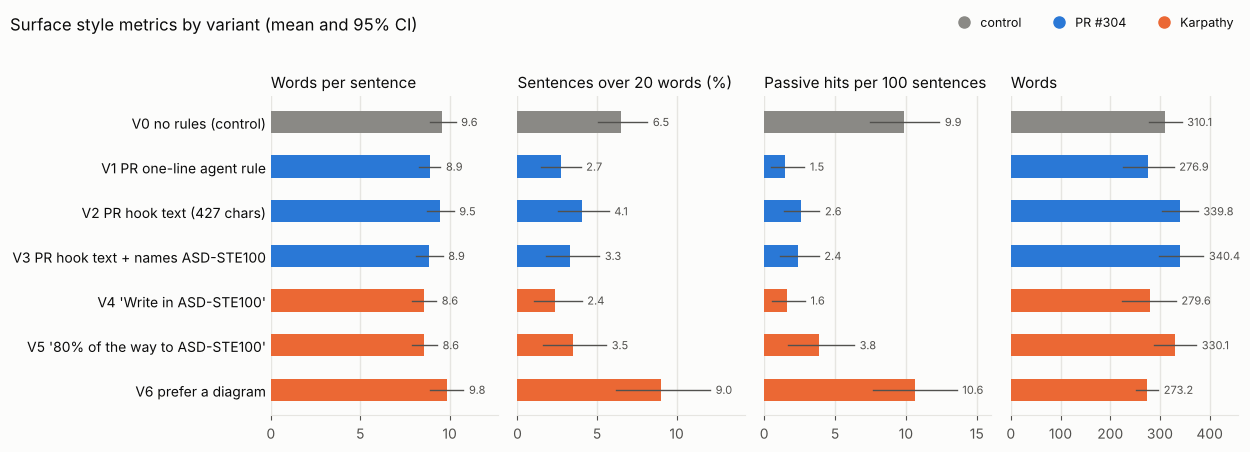

In [8]:
s2 = summarize(df, STYLE_COLS)
fig = bar_panels(
    s2, ["mean_sentence_words", "pct_sentences_over_20", "passive_per_100_sentences", "words"],
    "Surface style metrics by variant (mean and 95% CI)",
)

## Recall of planted facts, by task

The PR's judges complained that texts which named ASD-STE100 were missing content. This grid shows where content goes missing: the share of each task's planted facts that the judge found in the text.

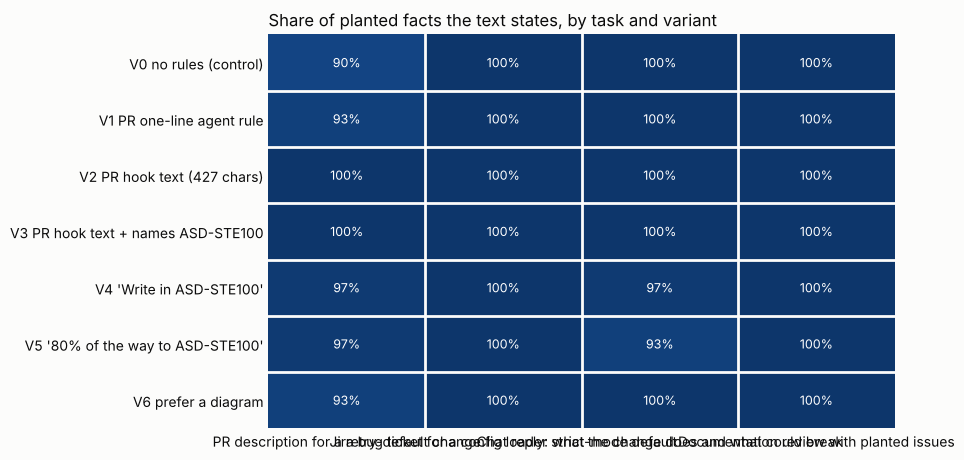

In [9]:
piv = df.pivot_table(index="variant_label", columns="task", values="facts_recall", aggfunc="mean", observed=True)
piv = piv.loc[[VARIANTS[v]["label"] for v in VORDER]]
piv.columns = [TASKS[t]["title"] for t in piv.columns]
fig = heatmap(piv, "Share of planted facts the text states, by task and variant")

## Accuracy details: traps, unsupported claims, and marked judgments

`Traps stated as fact` counts claims the source does not support that the text states anyway (for example a motive for a change that the ticket does not give). `Judgments marked` is the share of runs where every guess or judgment in the text was labelled as one. The last column counts a formatting quirk: the whole reply delivered inside a ```` ```markdown ```` code fence, which renders as raw text in a PR or ticket.

In [10]:
acc = wide_table(df, ["traps_hit_n", "unsupported_claims"], digits=2)
acc["Judgments marked (share of runs)"] = df.groupby("variant_label", observed=True)["judgments_marked"].mean().round(2).reindex(acc.index)
acc["Diagram present (share of runs)"] = df.groupby("variant_label", observed=True)["has_diagram"].mean().round(2).reindex(acc.index)
acc["Whole reply wrapped in a code fence (share of runs)"] = df.groupby("variant_label", observed=True)["wrapped_in_code_fence"].mean().round(2).reindex(acc.index)
acc

,Traps stated as fact,Unsupported claims,Judgments marked (share of runs),Diagram present (share of runs),Whole reply wrapped in a code fence (share of runs)
V0 no rules (control),"0.30 [0.10, 0.55]","0.85 [0.50, 1.20]",0.60,0.00,0.0
V1 PR one-line agent rule,"0.15 [0.00, 0.30]","0.45 [0.20, 0.75]",0.70,0.00,0.1
V2 PR hook text (427 chars),"0.00 [0.00, 0.00]","0.50 [0.20, 0.80]",0.85,0.00,0.0
V3 PR hook text + names ASD-STE100,"0.00 [0.00, 0.00]","0.35 [0.10, 0.60]",0.90,0.00,0.0
V4 'Write in ASD-STE100',"0.05 [0.00, 0.15]","1.00 [0.65, 1.35]",0.60,0.00,0.1
V5 '80% of the way to ASD-STE100',"0.10 [0.00, 0.25]","1.20 [0.70, 1.75]",0.45,0.00,0.0
V6 prefer a diagram,"0.20 [0.05, 0.40]","1.05 [0.65, 1.45]",0.65,0.65,0.0


## Cost, length, and time per run

Input tokens are nearly constant (about 3.5K, mostly cached after the first call of each variant), so cost tracks output and thinking tokens.

In [11]:
wide_table(df, COST_COLS, digits=3)

,Cost per run (USD),Output tokens,Thinking tokens,Wall time (s)
V0 no rules (control),"0.044 [0.041, 0.047]","1398.000 [1306.243, 1491.900]","406.000 [330.400, 488.550]","17.040 [16.155, 17.950]"
V1 PR one-line agent rule,"0.043 [0.040, 0.046]","1376.600 [1273.995, 1474.956]","426.100 [351.598, 499.551]","16.497 [15.356, 17.641]"
V2 PR hook text (427 chars),"0.046 [0.042, 0.050]","1520.550 [1343.390, 1696.256]","556.650 [425.199, 701.854]","18.259 [16.592, 19.962]"
V3 PR hook text + names ASD-STE100,"0.045 [0.042, 0.049]","1489.200 [1320.049, 1658.153]","528.100 [414.795, 649.750]","17.886 [16.210, 19.526]"
V4 'Write in ASD-STE100',"0.043 [0.041, 0.046]","1401.450 [1275.994, 1530.510]","423.550 [345.194, 505.420]","16.882 [15.616, 18.180]"
V5 '80% of the way to ASD-STE100',"0.043 [0.041, 0.046]","1379.050 [1261.046, 1499.812]","380.550 [314.298, 445.951]","17.003 [15.677, 18.326]"
V6 prefer a diagram,"0.044 [0.041, 0.046]","1415.550 [1318.994, 1508.206]","351.650 [291.645, 415.901]","17.108 [15.923, 18.268]"


## Side-by-side outputs

Repetition 0 of every variant for each task, in variant order. Nothing is cherry-picked. The line under each heading gives the word count, the mean sentence length, and the blind judge's scores for that exact text.

In [12]:
def show_task(task):
    t = TASKS[task]
    display(Markdown(f"## {t['title']}\n\n**Prompt given to the writer:**"))
    print(t["prompt"])
    display(Markdown("**Facts the judge checks:**\n\n" + "\n".join(f"{i + 1}. {f}" for i, f in enumerate(t["facts"]))))
    sub = df[(df.task == task) & (df.rep == 0)]
    for _, r in sub.iterrows():
        line = f"{r.words} words, {r.mean_sentence_words:.0f} words per sentence, {r.output_tokens} output tokens, ${r.cost_usd:.3f}"
        if "clarity" in r.index and pd.notna(r.clarity):
            line += (f". Judge: clarity {int(r.clarity)}, accuracy {int(r.accuracy)}, completeness {int(r.completeness)}, "
                     f"actionability {int(r.actionability)}, facts {sorted(r.facts_covered)} of {len(t['facts'])}, traps {sorted(r.traps_hit)}")
        display(Markdown(f"### {r.variant_label}\n\n*{line}*"))
        display(Markdown(r.output))
        if "notes" in r.index and isinstance(r.notes, str):
            display(Markdown(f"> **Judge notes:** {r.notes}"))
        display(Markdown("---"))

In [13]:
show_task('chat_reply')

## Chat reply: what the change does and what could break

**Prompt given to the writer:**

Here is a diff from the `cfgload` library. Explain what this change does and what could break for people who already use the config loader.

```diff
diff --git a/cfgload/__init__.py b/cfgload/__init__.py
--- a/cfgload/__init__.py
+++ b/cfgload/__init__.py
@@ -20,14 +20,14 @@ KNOWN_KEYS = {"name", "version", "env", "services", "secrets", "strict"}

-def load(path: str, strict: bool | None = None) -> dict:
-    """Load a YAML config. Unknown top-level keys raise KeyError when strict."""
+def load(path: str, strict: bool | None = True) -> dict:
+    """Load a YAML config. Unknown top-level keys raise KeyError unless strict is False."""
     data = _read_yaml(path)
     if strict is None:
-        strict = bool(data.get("strict", False))
+        strict = bool(data.get("strict", True))
     if strict:
         unknown = set(data) - KNOWN_KEYS
         if unknown:
             raise KeyError(f"unknown key: {sorted(unknown)[0]}")
     return data
```



**Facts the judge checks:**

1. The default of the `strict` parameter changes from `None` to `True`.
2. When `strict` is `None`, the fallback for a file without a `strict` key changes from `False` to `True`.
3. With the new default, a file's own `strict: false` key is ignored unless the caller passes `strict=None`, because the parameter default is `True`, not `None`.
4. Callers that never passed `strict` now get a `KeyError` on any unknown top-level key (typos, custom keys, plugin keys).
5. Passing `strict=False` keeps the old behavior.
6. The error names only the first unknown key in sorted order.

### V0 no rules (control)

*383 words, 15 words per sentence, 1541 output tokens, $0.044. Judge: clarity 5, accuracy 5, completeness 5, actionability 5, facts [1, 2, 3, 4, 5, 6] of 6, traps []*

# What the change does

There are two edits, and together they behave differently than either one alone.

1. **The default argument changes from `None` to `True`.** Calling `load(path)` with no `strict` argument now sets `strict=True` immediately.
2. **The fallback for the in-file `strict` key changes from `False` to `True`.** This only matters when `strict is None`.

The problem is that after edit 1, `strict is None` is only true when a caller explicitly writes `load(path, strict=None)`. So for the most common call, `load(path)`, the `strict:` key inside the YAML file is **never read**.

| Call | YAML `strict:` | Before | After |
|---|---|---|---|
| `load(p)` | absent | lenient | **strict** |
| `load(p)` | `false` | lenient | **strict (file setting ignored)** |
| `load(p)` | `true` | strict | strict |
| `load(p, strict=None)` | absent | lenient | **strict** |
| `load(p, strict=None)` | `false` | lenient | lenient |
| `load(p, strict=False/True)` | any | as passed | as passed |

# What could break for existing users

1. **Configs with extra top-level keys now fail.** This includes custom sections, YAML anchor blocks like `x-defaults:`, `description:` or `owner:` keys, and typos. Anything outside `KNOWN_KEYS` that used to load silently now raises `KeyError` when called as `load(path)`. This is a hard runtime failure, often at startup.

2. **`strict: false` in a config file stops working.** This is probably the most surprising break, and likely unintended. People who opted out of strict checking inside the file, rather than in code, lose that opt-out without any warning. The new docstring ("unless strict is False") makes this worse, because it reads as if the file setting still counts.

3. **Explicit `strict=None` callers become strict by default.** Code that passed `None` to mean "let the file decide" now gets strict behavior when the file doesn't set the key.

4. **Errors surface one key at a time.** This isn't new, but the change exposes it much more. The message reports only `sorted(unknown)[0]`, so a config with several unknown keys has to be fixed, re-run, and fixed again.

5. **Code that relies on `KeyError` meaning something else may misfire.** If callers wrap `load()` in `except KeyError` expecting a missing key from somewhere else, they will now catch this error too and may handle it incorrectly.

# Suggested fix

If the goal is "strict by default, but files and callers can still opt out," keep the `None` sentinel and change only the fallback:

```python
def load(path: str, strict: bool | None = None) -> dict:
    """Load a YAML config. Unknown top-level keys raise KeyError unless
    strict=False is passed or the file sets `strict: false`."""
    data = _read_yaml(path)
    if strict is None:
        strict = bool(data.get("strict", True))
    ...
```

This still breaks case 1, which is the intended behavior change, but it keeps `strict: false` in files working. Because case 1 is still breaking, it's worth a major version bump or a deprecation period: for one release, emit a `DeprecationWarning` when unknown keys are found and strict wasn't set either way, then switch to the new default. Reporting all unknown keys in the error message (`sorted(unknown)`) would also make the migration much less painful.

...

---

### V6 prefer a diagram

*215 words, 13 words per sentence, 1590 output tokens, $0.045. Judge: clarity 5, accuracy 4, completeness 5, actionability 5, facts [1, 2, 3, 4, 5, 6] of 6, traps []*

# What the change does

It flips `cfgload.load` from **lenient by default** to **strict by default**. It also has a side effect that the docstring doesn't mention: the file's own `strict:` key is now **ignored unless the caller passes `strict=None` explicitly**.

```
                         BEFORE                                  AFTER
load(path)          strict=None                             strict=True
                         │                                       │
                         ▼                                       ▼
              read `strict:` from file              file's `strict:` is never consulted
              (missing → False)                     → always strict
                         │                                       │
              unknown keys allowed                  unknown keys → KeyError
              unless file opts in

load(path, strict=None)  file decides, missing → False      file decides, missing → True
load(path, strict=True)  strict                             strict          (unchanged)
load(path, strict=False) lenient                            lenient         (unchanged)
```

The key line is `if strict is None:`. Before, that branch ran on every default call. Now it only runs when someone writes `strict=None` themselves.

# What could break

| # | Who is affected | Before | After |
|---|---|---|---|
| 1 | Callers using `load(path)` with configs that contain any key outside `KNOWN_KEYS` (e.g. `logging:`, `x-anchors:`, `description:`) | Loads fine | **`KeyError: unknown key: ...`** |
| 2 | Configs that opt out with `strict: false` in the YAML | Lenient | **Ignored.** Still strict, because the default call never reads the file's key. This is the nastiest one, since users did the documented thing and it silently stopped working. |
| 3 | Callers passing `strict=None` explicitly, with files that have no `strict:` key | Lenient | Strict, because the fallback changed from `False` to `True` |
| 4 | Code wrapping `load()` in `except KeyError` for other reasons, such as a missing-key lookup right after loading | — | That handler may now swallow the validation error and hide it |
| 5 | Callers passing `strict=True` or `strict=False` explicitly | — | No change |

# Other things worth flagging to the author

- **The docstring is misleading.** It says the error is raised "unless strict is False", which suggests a file-level `strict: false` works. Under the default call, it doesn't. Either document that only the argument counts, or keep `None` as the default and change only the fallback (`data.get("strict", True)`). The second option makes the library strict by default while still honouring per-file opt-outs, so it causes far less breakage. I'd recommend it.
- **Only the first unknown key is reported** (`sorted(unknown)[0]`). Users migrating a config with several extra keys will have to fix them one error at a time. Listing all of them would make the upgrade much less painful.
- **Already a problem before this change, but more exposed now:** `bool(data.get("strict"))` treats a quoted string like `strict: "false"` as `True`.
- **Release handling:** this is a breaking default change, so it should get a major version bump or a deprecation period (for example, warn on unknown keys for one release) and a changelog entry.

> **Judge notes:** The text covers all six facts and hits no traps. Its before/after diagram and its table of who is affected make the change in the parameter default, and its effect on the file's own `strict:` key, easy to follow. Two claims go beyond the source: it says the per-file `strict: false` opt-out was "documented", which the diff doesn't show. It also says that opt-out "silently stopped working", which overstates things, because affected callers now get a KeyError.

---

In [14]:
show_task('pr_description')

## PR description for a retry-default change

**Prompt given to the writer:**

Write the pull request description for this change. The repository is `tinyhttp`, a small HTTP client library. The PR title is already set: "Turn retries on by default (TH-212)". Write only the description body.

Ticket TH-212 reads, in full:

    Summary: Make retries on by default
    Description: (none)

Diff:

```diff
diff --git a/tinyhttp/client.py b/tinyhttp/client.py
--- a/tinyhttp/client.py
+++ b/tinyhttp/client.py
@@ -12,18 +12,31 @@ class Client:
-    def __init__(self, base_url: str, timeout: float = 10.0, max_retries: int = 0):
+    def __init__(
+        self,
+        base_url: str,
+        timeout: float = 10.0,
+        max_retries: int = 3,
+        backoff: float = 0.5,
+    ):
         self.base_url = base_url
         self.timeout = timeout
         self.max_retries = max_retries
+        self.backoff = backoff

     def request(self, method: str, path: str, **kwargs) -> Response:
-        return self._send(method, path, **kwargs)
+        attempt = 0
+        whil

**Facts the judge checks:**

1. The default for `max_retries` changes from 0 to 3.
2. A new `backoff` parameter (default 0.5 seconds) sets the wait before a retry, and the wait doubles on each attempt (0.5 s, 1 s, 2 s).
3. A retry happens on `ConnectionError` and on 502, 503, and 504 responses. Other responses return at once.
4. Retries apply to every HTTP method, including POST (`test_retries_post`), so a non-idempotent request can be sent up to 4 times.
5. Existing callers that did not pass `max_retries` now get up to 4 attempts and up to 3.5 s of added wait on failure.
6. The ticket gives no reason for the change.

### V0 no rules (control)

*319 words, 10 words per sentence, 1437 output tokens, $0.059. Judge: clarity 5, accuracy 4, completeness 5, actionability 5, facts [1, 2, 3, 4, 5, 6] of 6, traps []*

## Summary

Enables retries by default in `Client`, per TH-212. `max_retries` now defaults to `3` (was `0`), and a new `backoff` parameter (default `0.5`s) controls exponential backoff between attempts.

## Behavior

`Client.request` now retries when:

- `_send` raises `ConnectionError`, or
- the response status is `502`, `503`, or `504`.

The delay before retry *n* (0-indexed) is `backoff * 2**n`. With the defaults, that is 0.5s, 1s, then 2s, so a request that exhausts its retries adds up to **3.5s** of sleep on top of up to four request timeouts.

When retries run out:

- A `ConnectionError` is re-raised.
- A 5xx response is returned to the caller as-is, with no exception.

Callers can restore the old behavior with `Client(url, max_retries=0)`.

## ⚠️ Reviewer attention: non-idempotent methods are retried

Retries apply to **every HTTP method**, including `POST`. `test_retries_post` checks this deliberately. This is a behavior change for existing callers who construct `Client` without an explicit `max_retries`:

- A `POST` that reaches the server but fails on the way back (a dropped connection or a 502 from a proxy) will be re-sent. That can create duplicate side effects, such as a duplicate `/orders` entry.
- TH-212 has no description, so it doesn't say whether retrying non-idempotent methods by default is intended.

Options if this isn't intended:
1. Limit default retries to idempotent methods (`GET`, `HEAD`, `OPTIONS`, `PUT`, `DELETE`).
2. Add a per-request `retry=` override.
3. Keep the current behavior and call it out in the changelog as a breaking change.

## Other notes

- Timeouts are **not** retried. `TimeoutError`/`socket.timeout` is not a subclass of `ConnectionError`.
- There is no jitter, so many clients failing together will retry in sync.
- `Retry-After` headers on 503 responses are ignored.

## Tests

- Replaced `test_no_retry_by_default` with `test_three_retries_by_default`. With default settings, the request to `flaky_server` succeeds after 4 calls.
- Added `test_retries_post`, which confirms that `POST` is retried by default.

🤖 Generated with [Claude Code](https://claude.com/claude-code)

https://claude.ai/code/session_01FZLEqJNdUB4NAjj81gcGx3

---

*Not part of the description:* the diff uses `time.sleep` but doesn't show an `import time`. It may already be above line 12; if not, add it before merging.

...

---

### V6 prefer a diagram

*317 words, 10 words per sentence, 1740 output tokens, $0.059. Judge: clarity 4, accuracy 4, completeness 4, actionability 5, facts [1, 2, 3, 4, 5] of 6, traps []*

## Summary

Implements TH-212. `Client` now retries failed requests by default instead of failing on the first error.

- `max_retries` default changes from `0` to `3`.
- New `backoff` parameter (default `0.5`s) sets the base for exponential backoff between attempts.
- `request()` now retries on `ConnectionError` and on HTTP `502`, `503`, and `504` responses.

## Retry behavior

```
request(method, path)
        │
        ▼
   ┌─────────┐
   │ _send() │◄─────────────────────────────┐
   └────┬────┘                              │
        │                                   │
   ConnectionError?                         │
   ├─ yes ─ retries left? ─ no ──► raise     │
   │              └─ yes ──────────────┐    │
   └─ no ── status in 502/503/504?     │    │
            ├─ no ──────────► return   │    │
            └─ yes ─ retries left?     │    │
                     ├─ no ─► return   │    │
                     │   (last 5xx)    ▼    │
                     └─ yes ──► sleep(backoff * 2^attempt)
                                attempt += 1 ───┘
```

With the defaults, a request makes up to **4 attempts** (1 + 3 retries), with sleeps of 0.5s, 1s, and 2s between them.

| | Before | After |
|---|---|---|
| Attempts per request | 1 | up to 4 |
| Added sleep, worst case | 0s | 3.5s |
| Wall time, worst case (10s timeout) | ~10s | ~43.5s |
| 5xx after retries are used up | returned | returned (last response) |
| `ConnectionError` after retries are used up | raised | raised |

## ⚠️ Behavior change for existing callers

This is a **default change**, so it affects every existing caller that does not pass `max_retries` explicitly. To keep the old single-attempt behavior, callers can pass `Client(url, max_retries=0)`.

## Things for reviewers to decide

1. **Non-idempotent methods are retried.** Retries apply to all methods, including `POST`, `PATCH`, and `DELETE`. `test_retries_post` asserts that a `POST /orders` is sent 4 times. If the server processed the request but the connection dropped before the response arrived, retrying can cause duplicate side effects, such as duplicate orders. TH-212 does not specify a scope. A common choice is to retry only idempotent methods (`GET`, `HEAD`, `OPTIONS`, `PUT`, `DELETE`) by default and require an opt-in for others. **I recommend settling this before merging.**
2. **Worst-case latency.** Worst-case wall time goes from about 10s to about 43.5s. Callers that set their own deadlines may notice.
3. **`import time`.** The diff calls `time.sleep` but does not add an import. Please confirm that `time` is already imported in `client.py`.
4. **No jitter.** All clients back off on the same schedule. This is fine for now, but it is worth considering if many clients hit the same upstream at once.

## Tests

- Replaced `test_no_retry_by_default` with `test_three_retries_by_default`. A request against `flaky_server` now succeeds with status `200` after 4 calls.
- Added `test_retries_post`, which asserts that `POST` is also retried 4 times. (Update this if we change point 1 above.)
- There are no tests yet for the `502`/`503`/`504` paths, for raising after retries are used up, or for the backoff timing.

🤖 Generated with [Claude Code](https://claude.com/claude-code)

https://claude.ai/code/session_01FZLEqJNdUB4NAjj81gcGx3

> **Judge notes:** Strength: the text covers the new defaults, backoff schedule, retry conditions, worst-case cost, and the risk of retrying POST, and it gives callers a clear opt-out and reviewers clear decisions to make. Weaknesses: it lists DELETE as non-idempotent and then as idempotent, which contradicts itself, and it never says outright that TH-212 gives no reason for the change. The ASCII flowchart adds bulk without adding much.

---

In [15]:
show_task('jira_ticket')

## Jira bug ticket for a config loader strict-mode default

**Prompt given to the writer:**

Write a Jira bug ticket from the report below. Use these sections: Summary (one line), Environment, Steps to reproduce, Expected result, Actual result, Notes.

Report from a user in #help-cfgload:

> After we upgraded cfgload from 2.3.0 to 2.4.0, our deploy job fails on start.
> `cfgload.load("deploy.yaml")` raises `KeyError: 'unknown key: feature_flags'`.
> deploy.yaml has a top-level `feature_flags:` block that our own plugin reads.
> The file has no `strict` key. We never pass `strict=` to `load()`.
> In 2.3.0 the same file loaded fine. Python 3.12, Ubuntu 22.04.

Traceback they pasted:

    Traceback (most recent call last):
      File "/app/deploy.py", line 14, in <module>
        cfg = cfgload.load("deploy.yaml")
      File "/usr/lib/python3.12/site-packages/cfgload/__init__.py", line 41, in load
        raise KeyError(f"unknown key: {sorted(unknown)[0]}")
    KeyError: 'unknown key: feature_flags'

cfgload 2.4.0 CHANGELOG entry:

    - `load()` now defaults to strict mode (#88).

**Facts the judge checks:**

1. The summary names `cfgload.load`, the `KeyError`, and the unknown key or the 2.4.0 strict default.
2. The file loaded in 2.3.0 and fails in 2.4.0.
3. Environment: cfgload 2.4.0, Python 3.12, Ubuntu 22.04.
4. Steps: a config file with a top-level key that is not a known key (`feature_flags`), no `strict` key in the file, and a call to `load()` without `strict=`.
5. Expected: the file loads as in 2.3.0. Actual: `KeyError: 'unknown key: feature_flags'` raised from `cfgload/__init__.py` line 41.
6. The 2.4.0 changelog says strict mode is now the default (#88) and that `strict=False` keeps the old behavior.

### V0 no rules (control)

*268 words, 7 words per sentence, 1021 output tokens, $0.034. Judge: clarity 5, accuracy 4, completeness 5, actionability 5, facts [1, 2, 3, 4, 5, 6] of 6, traps [1]*

**Summary**
`cfgload.load()` raises `KeyError` on unknown top-level keys after upgrade from 2.3.0 to 2.4.0 (strict mode now on by default)

**Environment**
- cfgload: 2.4.0 (last working: 2.3.0)
- Python: 3.12
- OS: Ubuntu 22.04
- Reported in: #help-cfgload

**Steps to reproduce**
1. Install cfgload 2.4.0.
2. Create `deploy.yaml` with a top-level key that cfgload doesn't recognize. The reporter's file has a `feature_flags:` block that their own plugin reads. Do not add a `strict` key.
3. Call `cfgload.load("deploy.yaml")` without passing `strict=`.

**Expected result**
The file loads as it did in 2.3.0. Unknown top-level keys are kept in the result for downstream consumers, such as the reporter's plugin.

**Actual result**
`load()` raises:

```
Traceback (most recent call last):
  File "/app/deploy.py", line 14, in <module>
    cfg = cfgload.load("deploy.yaml")
  File "/usr/lib/python3.12/site-packages/cfgload/__init__.py", line 41, in load
    raise KeyError(f"unknown key: {sorted(unknown)[0]}")
KeyError: 'unknown key: feature_flags'
```

The reporter's deploy job fails on startup.

**Notes**
- **This matches documented 2.4.0 behavior.** The CHANGELOG says: "`load()` now defaults to strict mode (#88). Unknown top-level keys raise `KeyError`. Pass `strict=False` to keep the old behavior." The code is doing what #88 intended. The real problem is that a breaking default change shipped in a minor release.
- **Workaround:** call `cfgload.load("deploy.yaml", strict=False)`, or pin `cfgload<2.4`.
- **Points for triage:**
  - Should the strict default be reverted in a 2.4.x patch and moved to 3.0, following semver? Or should 2.4.0 get a deprecation warning period first?
  - The error lists only the first unknown key (`sorted(unknown)[0]`). Users with several unknown keys have to fix them one at a time. Consider listing all of them.
  - The error message could name the fix, for example: "…pass `strict=False` to allow extra keys."
  - Plugin-owned top-level keys seem to be a supported pattern. Consider a way to allow or register extra keys under strict mode, so users don't have to turn strict mode off entirely.
- Related: #88

...

---

### V6 prefer a diagram

*210 words, 8 words per sentence, 1159 output tokens, $0.037. Judge: clarity 4, accuracy 3, completeness 5, actionability 5, facts [1, 2, 3, 4, 5, 6] of 6, traps [1]*

**Summary:** `load()` raises `KeyError` on unknown top-level keys after upgrading 2.3.0 → 2.4.0 (strict mode became the default in a minor release)

**Environment**
- cfgload 2.4.0 (regression from 2.3.0)
- Python 3.12
- Ubuntu 22.04
- Reported in #help-cfgload

**Steps to reproduce**
1. Create `deploy.yaml` with a top-level key that cfgload doesn't recognize, e.g.:
   ```yaml
   feature_flags:
     some_flag: true
   ```
   Do not include a `strict` key.
2. Install cfgload 2.4.0.
3. Run:
   ```python
   import cfgload
   cfg = cfgload.load("deploy.yaml")
   ```

**Expected result**
The file loads without error, as it did in 2.3.0. Unknown top-level keys such as `feature_flags`, which the reporter's own plugin reads, are left alone.

**Actual result**
`load()` raises `KeyError`:
```
Traceback (most recent call last):
  File "/app/deploy.py", line 14, in <module>
    cfg = cfgload.load("deploy.yaml")
  File "/usr/lib/python3.12/site-packages/cfgload/__init__.py", line 41, in load
    raise KeyError(f"unknown key: {sorted(unknown)[0]}")
KeyError: 'unknown key: feature_flags'
```
The reporter's deploy job fails on startup.

**Notes**
- This is the documented 2.4.0 change from #88: *"`load()` now defaults to strict mode. Unknown top-level keys raise `KeyError`. Pass `strict=False` to keep the old behavior."* The code behaves as the changelog says. The problem is that the default changed in a minor release. That breaks semver expectations, and callers who never opted in now fail.
- **Workaround:** `cfgload.load("deploy.yaml", strict=False)`, or pin `cfgload<2.4`.
- Options to decide on:
  ```
  2.4.0 default strict=True ──► breaks existing callers
     ├─ A) Revert default to strict=False in 2.4.x; add a DeprecationWarning for unknown keys; flip in 3.0
     ├─ B) Keep strict default; add a way to register or allow extension keys (e.g. allowed_keys=…)
     └─ C) Keep as is; close as "working as intended", improve the changelog and upgrade notes
  ```
  Recommend **A**, which follows semver, plus **B** as a follow-up so plugins that read extension keys can work under strict mode.
- Minor: the error reports only the first unknown key (`sorted(unknown)[0]`). Listing all of them, and suggesting `strict=False` in the message, would make this easier to diagnose.

> **Judge notes:** The ticket covers all six facts. It quotes the full traceback and changelog, and its workaround and options give the reader clear next steps. Its main weakness is in the Notes. It says as fact that "the problem is" the default changing in a minor release and that this "breaks semver expectations". It also calls the change a "regression". These are judgments, and the source never says cfgload follows semver. The options tree and the recommendation for A take up a lot of a bug ticket.

---

In [16]:
show_task('doc_review')

## Documentation review with planted issues

**Prompt given to the writer:**

You are reviewing the documentation in this pull request to the `cfgload` library. Return a numbered list of findings. For each finding give the file and lines, what is wrong, and the fix. If the documentation is correct, say so.

```diff
diff --git a/cfgload/__init__.py b/cfgload/__init__.py
--- a/cfgload/__init__.py
+++ b/cfgload/__init__.py
@@ -1,4 +1,4 @@
-__version__ = "2.4.0"
+__version__ = "2.4.1"
@@ -36,3 +36,30 @@ def load(path: str, strict: bool | None = True) -> dict:
     return data
+
+
+def load_many(paths: list[str], strict: bool | None = True, skip_missing: bool = False) -> dict[str, dict]:
+    """Load several YAML config files.
+
+    Args:
+        paths: Paths to the config files, in load order.
+        strict: Passed to ``load`` for each file.
+        ignore_missing: If True, skip paths that do not exist instead of raising.
+
+    Returns:
+        A list of dicts, one per path, in the same order as ``paths``.
+    """
+    out: dict[str, dict] = {}
+    for path

**Facts the judge checks:**

1. The docstring `Returns` section says a list of dicts, but the function returns a dict keyed by path.
2. The docstring documents a parameter `ignore_missing`, but the parameter is named `skip_missing`.
3. The README example passes `ignore_missing=True`, which is not a parameter of `load_many` and fails with `TypeError`.
4. The README example iterates `for cfg in configs` and reads `cfg['name']`; iterating the returned dict yields path strings, so this fails.
5. The docstring has no `Raises` section for the `FileNotFoundError` raised when `skip_missing` is False.
6. The CHANGELOG heading says 2.5.0 but `__version__` is bumped to 2.4.1, so the two disagree.

### V0 no rules (control)

*237 words, 8 words per sentence, 1557 output tokens, $0.048. Judge: clarity 5, accuracy 5, completeness 5, actionability 5, facts [1, 2, 3, 4, 5, 6] of 6, traps []*

## Findings

1. **`cfgload/__init__.py` ~line 45 (docstring `Args`)**
   - **Problem:** The docstring documents a parameter named `ignore_missing`, but the signature names it `skip_missing`.
   - **Fix:** `skip_missing: If True, skip paths that do not exist instead of raising.`

2. **`cfgload/__init__.py` ~lines 47–48 (docstring `Returns`)**
   - **Problem:** The docstring says the function returns "a list of dicts, one per path, in the same order as `paths`." It actually returns a `dict[str, dict]` keyed by path. Missing paths that were skipped are absent from the result.
   - **Fix:** `A dict mapping each loaded path to its parsed config, in the same order as ``paths``. Paths skipped because of ``skip_missing`` are omitted.`
   - **Optional:** If a path appears twice in `paths`, only one entry survives. Mention this if it matters.

3. **`cfgload/__init__.py` docstring (missing section)**
   - **Problem:** The function raises `FileNotFoundError` when a path is missing and `skip_missing` is False, but the docstring doesn't say so.
   - **Fix:** Add a section:
     ```
     Raises:
         FileNotFoundError: If a path does not exist and ``skip_missing`` is False.
     ```

4. **`README.md` line 33**
   - **Problem:** The example calls `load_many(..., ignore_missing=True)`. That keyword doesn't exist, so the call raises `TypeError: unexpected keyword argument`.
   - **Fix:** Use `skip_missing=True`.

5. **`README.md` lines 34–35**
   - **Problem:** `for cfg in configs:` iterates over the dict's keys, which are path strings. So `cfg["name"]` raises `TypeError: string indices must be integers`.
   - **Fix:** Iterate over the values:
     ```python
     for path, cfg in configs.items():
         print(path, cfg["name"])
     ```
     `for cfg in configs.values():` also works.

6. **`CHANGELOG.md` line 1 vs `cfgload/__init__.py` line 1**
   - **Problem:** The changelog entry is headed `## 2.5.0`, but `__version__` is bumped to `"2.4.1"`. Adding a new public function is a minor-version change under semver, so 2.5.0 is the correct number.
   - **Fix:** Change `__version__` to `"2.5.0"` so the two match.

## Summary

The documentation is not correct as written. Items 4 and 5 mean the README example fails at runtime. Items 1, 2 and 6 are factual mismatches between the docs and the code.

...

---

### V6 prefer a diagram

*236 words, 8 words per sentence, 1541 output tokens, $0.047. Judge: clarity 5, accuracy 5, completeness 5, actionability 5, facts [1, 2, 3, 4, 5, 6] of 6, traps []*

The documentation is **not correct**. Several examples would fail at runtime, and the version numbers disagree.

1. **`cfgload/__init__.py`, docstring `Args`: wrong parameter name**
   - **Problem:** The docstring documents `ignore_missing`, but the signature uses `skip_missing`.
   - **Fix:** Rename it in the docstring:
     ```
     skip_missing: If True, skip paths that do not exist instead of raising.
     ```

2. **`cfgload/__init__.py`, docstring `Returns`: wrong return type and shape**
   - **Problem:** The docstring says the function returns "a list of dicts, one per path". The code returns a `dict[str, dict]` keyed by path. When `skip_missing=True`, missing paths have no entry, so it is not "one per path".
   - **Fix:**
     ```
     Returns:
         A dict mapping each loaded path to its parsed config, in the same
         order as ``paths``. Paths skipped via ``skip_missing`` are omitted.
     ```

3. **`cfgload/__init__.py`, docstring: missing `Raises` section**
   - **Problem:** The function raises `FileNotFoundError` when a path is missing and `skip_missing=False`, but the docstring does not say so.
   - **Fix:** Add:
     ```
     Raises:
         FileNotFoundError: If a path does not exist and ``skip_missing`` is False.
     ```

4. **`README.md`, new example line 3: wrong keyword argument**
   - **Problem:** `ignore_missing=True` raises `TypeError: unexpected keyword argument`.
   - **Fix:** Use `skip_missing=True`.

5. **`README.md`, new example lines 4–5: wrong iteration**
   - **Problem:** `for cfg in configs` iterates over the dict's keys, which are path strings. `cfg["name"]` then raises `TypeError: string indices must be integers`.
   - **Fix:**
     ```python
     configs = cfgload.load_many(["base.yaml", "prod.yaml"], skip_missing=True)
     for path, cfg in configs.items():
         print(path, cfg["name"])
     ```

6. **`CHANGELOG.md` line 1 vs `cfgload/__init__.py` line 1: version mismatch**
   - **Problem:** The changelog heading says `2.5.0`, but `__version__` is bumped to `2.4.1`.
   - **Fix:** Set `__version__ = "2.5.0"`. Adding a public function is a minor release under semver, so the changelog has the right number.

7. **`CHANGELOG.md`, new entry: incomplete (minor)**
   - **Problem:** The entry does not mention the `skip_missing` option or what the function returns.
   - **Fix:**
     ```
     - Add `load_many()` to load several config files in one call. Returns a
       dict keyed by path; pass `skip_missing=True` to ignore absent files.
     ```

**Code issue to check (not documentation):** `load_many` calls `os.path.exists`, but the diff does not show `import os`. Confirm that `os` is already imported at the top of `cfgload/__init__.py`.

> **Judge notes:** The review reports all six planted issues, and each one names the file and location, says what is wrong and gives a concrete fix. Two items go beyond the planted issues: a changelog finding the writer labels minor, and the missing `import os`. The import point is set apart as a code issue to check, not a documentation finding, so it does not count as the trap. The text recommends 2.5.0 as the correct version and backs this with a semver reason. The source does not say which number the authors intended, but the recommendation is reasonable.

---

## Discussion

_Discussion to be written after the results are in._

## Reproduce

```bash
cd writing_style_variants
uv sync
uv run python run_variants.py --reps 5 --workers 6   # 140 headless Claude Code calls
uv run python judge.py --workers 6                   # 140 blind judge calls
uv run python build_notebook.py                      # rebuilds this notebook with outputs
```

`run_variants.py` and `judge.py` are resumable: cells already in `results/*.jsonl` are skipped.